In [1]:
# Импорты сюдаа
import numpy as np
import matplotlib.pyplot as plt
import segyio
import segyio.tools
from scipy.signal import correlate
from scipy.stats import spearmanr
from scipy.signal import find_peaks, hilbert
from scipy.optimize import minimize_scalar, minimize

In [2]:
class SeismicTraceGenerator:
    """
    Генератор синтетических сейсмических трасс с возможностью подбора параметров.
    Объединяет функциональность RickerWaveletGenerator, ReflectionCoefficients,
    SeismicTraceGenerator и AdjustableSeismicModel.
    """
    
    def __init__(self, dt=0.001, total_time=2.0, wavelet_freq=30, noise_level=0.0):
        """
        Инициализация генератора.
        
        Параметры:
        ----------
        dt : float
            интервал дискретизации в секундах
        total_time : float
            полное время записи в секундах
        wavelet_freq : float
            доминантная частота вейвлета в Гц
        noise_level : float
            уровень шума (0 = без шума, 0.05 = 5% от RMS сигнала)
        """
        self.dt = dt
        self.total_time = total_time
        self.wavelet_freq = wavelet_freq
        self.noise_level = noise_level
        
        # Временная ось
        self.time = np.arange(0, total_time, dt)
        self.num_samples = len(self.time)
        
        # Параметры модели (будут установлены позже)
        self.depths = None      # глубины границ (м)
        self.velocities = None  # скорости в слоях (м/с)
        self.densities = None   # плотности в слоях (кг/м³)
        
        # Кэш для вейвлета
        self._wavelet_cache = None
        self._wavelet_time_cache = None
        
    def set_horizons(self, depths, velocities, densities):
        """
        Устанавливает геометрию слоёв.
        
        Параметры:
        ----------
        depths : list или np.ndarray
            глубины границ от поверхности (м)
        velocities : list или np.ndarray
            скорости в слоях (м/с) (len = len(depths) + 1)
        densities : list или np.ndarray
            плотности в слоях (кг/м³) (len = len(depths) + 1)
        """
        self.depths = np.array(depths)
        self.velocities = np.array(velocities)
        self.densities = np.array(densities)
        
        # Проверка корректности размеров
        if len(self.velocities) != len(self.depths) + 1:
            raise ValueError(f"velocities должно быть на 1 больше depths: "
                           f"len(velocities)={len(self.velocities)}, "
                           f"len(depths)={len(self.depths)}")
        if len(self.densities) != len(self.depths) + 1:
            raise ValueError(f"densities должно быть на 1 больше depths")
    
    def set_wavelet_freq(self, freq):
        """Устанавливает частоту вейвлета и сбрасывает кэш."""
        self.wavelet_freq = freq
        self._wavelet_cache = None  # сбрасываем кэш
    
    def set_noise(self, noise_level):
        """Устанавливает уровень шума."""
        self.noise_level = noise_level
    
    def _create_ricker_wavelet(self):
        """
        Создаёт вейвлет Рикера с текущей частотой.
        
        Формула: (1 - 2π²f²t²) * exp(-π²f²t²)
        
        Возвращает:
        ----------
        wavelet_time : np.ndarray
            временная ось вейвлета
        wavelet : np.ndarray
            амплитуды вейвлета
        """
        # Длина вейвлета (3-4 периода)
        length = 4.0 / self.wavelet_freq
        
        wavelet_time = np.arange(-length/2, length/2, self.dt)
        tau = np.pi * self.wavelet_freq * wavelet_time
        wavelet = (1 - 2 * tau**2) * np.exp(-tau**2)
        
        return wavelet_time, wavelet
    
    def get_wavelet(self):
        """Возвращает вейвлет (с кэшированием)."""
        if self._wavelet_cache is None:
            self._wavelet_time_cache, self._wavelet_cache = self._create_ricker_wavelet()
        return self._wavelet_time_cache, self._wavelet_cache
    
    def _compute_impedances(self):
        """Вычисляет акустический импеданс для каждого слоя."""
        return self.densities * self.velocities
    
    def _compute_reflection_coeffs(self):
        """
        Вычисляет коэффициенты отражения на границах.
        
        Формула: R = (Z₂ - Z₁) / (Z₂ + Z₁)
        
        Возвращает:
        ----------
        coeffs : np.ndarray
            коэффициенты отражения на границах
        """
        impedances = self._compute_impedances()
        coeffs = []
        
        for i in range(len(self.depths)):
            Z_upper = impedances[i]
            Z_lower = impedances[i+1]
            R = (Z_lower - Z_upper) / (Z_lower + Z_upper)
            coeffs.append(R)
        
        return np.array(coeffs)
    
    def _compute_two_way_times(self):
        """
        Вычисляет двустороннее время прихода отражений.
        
        Возвращает:
        ----------
        times : np.ndarray
            времена прихода для каждой границы (с)
        """
        times = []
        cumulative = 0.0
        
        for i in range(len(self.depths)):
            if i == 0:
                thickness = self.depths[0]
            else:
                thickness = self.depths[i] - self.depths[i-1]
            
            cumulative += 2 * thickness / self.velocities[i]
            times.append(cumulative)
        
        return np.array(times)
    
    def get_reflectivity_series(self):
        """
        Преобразует коэффициенты отражения в дискретный временной ряд.
        
        Возвращает:
        ----------
        reflectivity : np.ndarray
            временной ряд коэффициентов отражения
        """
        coeffs = self._compute_reflection_coeffs()
        times = self._compute_two_way_times()
        
        reflectivity = np.zeros(self.num_samples)
        
        for t, r in zip(times, coeffs):
            idx = int(round(t / self.dt))
            if idx < self.num_samples:
                reflectivity[idx] = r
        
        return reflectivity, times, coeffs
    
    def _add_noise(self, trace):
        """Добавляет шум к трассе."""
        if self.noise_level <= 0:
            return trace
        
        rms = np.sqrt(np.mean(trace**2))
        if rms > 0:
            noise = np.random.randn(len(trace)) * self.noise_level * rms
            return trace + noise
        return trace
    
    def generate_trace(self):
        """
        Генерирует синтетическую трассу с текущими параметрами.
        
        Возвращает:
        ----------
        trace : np.ndarray
            синтетическая трасса
        times : np.ndarray
            времена прихода отражений (с)
        coeffs : np.ndarray
            коэффициенты отражения
        """
        # Получаем серию коэффициентов отражения
        reflectivity, times, coeffs = self.get_reflectivity_series()
        
        # Получаем вейвлет
        _, wavelet = self.get_wavelet()
        
        # Свёртка
        trace_full = np.convolve(reflectivity, wavelet, mode='full')
        trace = trace_full[:self.num_samples]
        
        # Добавляем шум
        trace = self._add_noise(trace)
        
        return trace, times, coeffs
    
    def compare_with_real(self, real_trace):
        """
        Сравнивает синтетическую трассу с реальной.
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса
            
        Возвращает:
        ----------
        metrics : dict
            словарь с метриками качества
        """
        synth_trace, _, _ = self.generate_trace()
        
        # Обрезаем до одинаковой длины
        min_len = min(len(synth_trace), len(real_trace))
        synth = synth_trace[:min_len]
        real = real_trace[:min_len]
        
        # Коэффициент корреляции Пирсона
        corr = np.corrcoef(synth, real)[0, 1]
        
        # Коэффициент ранговой корреляции Спирмена
        spearman = spearmanr(synth, real)[0]
        
        # Ошибки
        mse = np.mean((synth - real) ** 2)
        mae = np.mean(np.abs(synth - real))
        
        return {
            'pearson': corr,
            'spearman': spearman,
            'mse': mse,
            'mae': mae,
            'synth_trace': synth
        }
    
    def compare_with_events(self, events, time_tolerance=0.01):
        """
        Сравнивает времена прихода модели с выделенными событиями.
        
        Параметры:
        ----------
        events : list
            список событий из RealTraceLoader.extract_events
        time_tolerance : float
            допустимое отклонение времени (с)
            
        Возвращает:
        ----------
        metrics : dict
            метрики сравнения времён
        """
        _, model_times, _ = self.get_reflectivity_series()
        
        event_times = [e['time'] for e in events]
        
        matched_times = []
        matched_amplitudes = []
        
        for mt in model_times:
            diffs = np.abs(np.array(event_times) - mt)
            min_diff = np.min(diffs) if len(diffs) > 0 else np.inf
            if min_diff <= time_tolerance:
                matched_times.append(mt)
                idx = np.argmin(diffs)
                matched_amplitudes.append(events[idx]['amplitude'])
        
        if len(matched_times) > 0:
            time_error = np.mean(np.abs(np.array(matched_times) - np.array(event_times[:len(matched_times)])))
        else:
            time_error = np.inf
        
        return {
            'n_matched': len(matched_times),
            'n_model': len(model_times),
            'n_events': len(event_times),
            'mean_time_error': time_error,
            'matched_times': matched_times
        }
    
    def plot_trace(self, trace=None, title="Сейсмическая трасса", events=None):
        """
        Визуализирует трассу с отметкой событий.
        
        Параметры:
        ----------
        trace : np.ndarray, optional
            трасса (если None, генерируется новая)
        title : str
            заголовок графика
        events : list, optional
            список событий для отметки
        """
        if trace is None:
            trace, _, _ = self.generate_trace()
        
        plt.figure(figsize=(12, 6))
        plt.plot(self.time[:len(trace)], trace, 'b-', linewidth=1, label='Трасса')
        
        if events:
            for e in events:
                color = 'r' if e['type'] == 'positive' else 'g'
                plt.plot(e['time'], e['amplitude'], 'o', color=color, markersize=8)
                plt.text(e['time'], e['amplitude'], f"{e['time']:.2f}s", 
                        fontsize=9, ha='center', va='bottom' if e['type'] == 'positive' else 'top')
        
        plt.title(title)
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    def plot_comparison(self, real_trace, events=None):
        """
        Визуализирует сравнение синтетической и реальной трассы.
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса
        events : list, optional
            список событий для отметки на графике
        """
        synth_trace, times, coeffs = self.generate_trace()
        min_len = min(len(synth_trace), len(real_trace))
        time_axis = self.time[:min_len]
        
        metrics = self.compare_with_real(real_trace)
        
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        
        # График трасс
        axes[0].plot(time_axis, real_trace[:min_len], 'b-', 
                    label='Реальная трасса', alpha=0.8, linewidth=1)
        axes[0].plot(time_axis, synth_trace[:min_len], 'r-', 
                    label='Синтетическая трасса', alpha=0.8, linewidth=1)
        
        # Отмечаем времена прихода модели
        for t in times:
            axes[0].axvline(x=t, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
        
        # Отмечаем события, если переданы
        if events:
            for e in events[:10]:
                color = 'green' if e['type'] == 'positive' else 'orange'
                axes[0].axvline(x=e['time'], color=color, linestyle=':', alpha=0.5, linewidth=0.8)
        
        axes[0].set_title(f'Сравнение трасс (корреляция = {metrics["pearson"]:.4f})')
        axes[0].set_xlabel('Время (с)')
        axes[0].set_ylabel('Амплитуда')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # График разности
        diff = synth_trace[:min_len] - real_trace[:min_len]
        axes[1].plot(time_axis, diff, 'g-', linewidth=0.8)
        axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[1].fill_between(time_axis, diff, 0, alpha=0.3, color='green')
        axes[1].set_title(f'Разность (MSE = {metrics["mse"]:.6f}, MAE = {metrics["mae"]:.6f})')
        axes[1].set_xlabel('Время (с)')
        axes[1].set_ylabel('Разность')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def print_summary(self):
        """Выводит текущие параметры модели в консоль."""
        print("ТЕКУЩАЯ МОДЕЛЬ")
        
        if self.depths is not None:
            print("\nГеометрия слоёв:")
            print(f"  Глубины границ (м): {[f'{d:.1f}' for d in self.depths]}")
            print(f"  Скорости (м/с): {[f'{v:.0f}' for v in self.velocities]}")
            print(f"  Плотности (кг/м³): {[f'{rho:.0f}' for rho in self.densities]}")
            
            # Таблица слоёв
            print("\n  Детальная таблица слоёв:")
            print("  " + "-" * 70)
            print(f"  {'Слой':<6} {'Глубина (м)':<12} {'V (м/с)':<10} {'ρ (кг/м³)':<12} {'Импеданс':<15}")
            print("  " + "-" * 70)
            
            impedances = self._compute_impedances()
            for i in range(len(self.velocities)):
                depth = self.depths[i] if i < len(self.depths) else "∞"
                print(f"  {i:<6} {depth:<12} {self.velocities[i]:<10.0f} "
                      f"{self.densities[i]:<12.0f} {impedances[i]:<15.2f}")
        
        print(f"\nПараметры сигнала:")
        print(f"  Частота вейвлета: {self.wavelet_freq:.1f} Гц")
        print(f"  Уровень шума: {self.noise_level:.4f}")
        print(f"  dt: {self.dt*1000:.3f} мс")
        print(f"  Длительность: {self.total_time:.2f} с")
    
    def save_results(self, real_trace, filename="model_results.txt"):
        """
        Сохраняет параметры модели и метрики в файл.
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса для сравнения
        filename : str
            имя выходного файла
        """
        metrics = self.compare_with_real(real_trace)
        _, times, coeffs = self.get_reflectivity_series()
        
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("РЕЗУЛЬТАТЫ НАСТРОЙКИ ФИЗИЧЕСКОЙ МОДЕЛИ\n")
            f.write("=" * 50 + "\n\n")
            
            f.write("ПАРАМЕТРЫ МОДЕЛИ:\n")
            f.write(f"  Глубины границ (м): {self.depths}\n")
            f.write(f"  Скорости в слоях (м/с): {self.velocities}\n")
            f.write(f"  Плотности (кг/м³): {self.densities}\n")
            f.write(f"  Частота вейвлета: {self.wavelet_freq} Гц\n")
            f.write(f"  Уровень шума: {self.noise_level}\n\n")
            
            f.write("РАССЧИТАННЫЕ ПАРАМЕТРЫ:\n")
            f.write(f"  Времена прихода (с): {[f'{t:.3f}' for t in times]}\n")
            f.write(f"  Коэффициенты отражения: {[f'{r:.3f}' for r in coeffs]}\n\n")
            
            f.write("МЕТРИКИ КАЧЕСТВА:\n")
            f.write(f"  Pearson: {metrics['pearson']:.4f}\n")
            f.write(f"  Spearman: {metrics['spearman']:.4f}\n")
            f.write(f"  MSE: {metrics['mse']:.6f}\n")
            f.write(f"  MAE: {metrics['mae']:.6f}\n")
        
        print(f"\nРезультаты сохранены в {filename}")
    
    # ==================== МЕТОДЫ ДЛЯ ПОДБОРА ПАРАМЕТРОВ ====================
    
    def optimize_wavelet_freq(self, real_trace, freq_range=(10, 80)):
        """
        Оптимизирует частоту вейвлета.
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса
        freq_range : tuple
            диапазон частот для поиска (мин, макс)
        
        Возвращает:
        ----------
        best_freq : float
            оптимальная частота
        """
        def objective(f):
            self.set_wavelet_freq(f)
            metrics = self.compare_with_real(real_trace)
            return -metrics['pearson']  # минимизируем отрицательную корреляцию
        
        result = minimize_scalar(objective, bounds=freq_range, method='bounded')
        best_freq = result.x
        self.set_wavelet_freq(best_freq)
        
        print(f"Оптимальная частота: {best_freq:.1f} Гц (корреляция = {-result.fun:.4f})")
        return best_freq
    
    def optimize_amplitudes_simple(self, real_trace, event_indices=None, scale_range=(0.5, 2.0)):
        """
        Оптимизирует амплитуды (коэффициенты отражения) путём масштабирования плотностей.
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса
        event_indices : list, optional
            индексы горизонтов для оптимизации (если None, все)
        scale_range : tuple
            диапазон масштабирования плотностей
        
        Возвращает:
        ----------
        best_scales : list
            оптимальные масштабы для каждого слоя
        """
        if self.depths is None:
            raise ValueError("Модель не инициализирована. Сначала вызовите set_horizons().")
        
        n_layers = len(self.velocities)
        
        if event_indices is None:
            event_indices = range(1, n_layers)  # все слои, кроме первого
        
        original_densities = self.densities.copy()
        
        def objective(scales):
            # scales — массив масштабов для каждого слоя
            new_densities = original_densities.copy()
            for i, scale in enumerate(scales):
                new_densities[i+1] = original_densities[i+1] * scale
            self.densities = new_densities
            metrics = self.compare_with_real(real_trace)
            return -metrics['pearson']
        
        # Начальное приближение
        x0 = np.ones(len(event_indices))
        bounds = [scale_range] * len(event_indices)
        
        result = minimize(objective, x0, bounds=bounds, method='L-BFGS-B')
        
        # Применяем оптимальные масштабы
        for i, scale in enumerate(result.x):
            self.densities[event_indices[i]+1] = original_densities[event_indices[i]+1] * scale
        
        print(f"Оптимальные масштабы для слоёв {event_indices}: {[f'{s:.3f}' for s in result.x]}")
        print(f"Корреляция улучшена до: {-result.fun:.4f}")
        
        return result.x
    
    def optimize_depths(self, real_trace, depth_bounds=None):
        """
        Оптимизирует глубины границ.
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса
        depth_bounds : list of tuples, optional
            границы для каждой глубины [(min, max), ...]
        
        Возвращает:
        ----------
        best_depths : np.ndarray
            оптимальные глубины
        """
        if self.depths is None:
            raise ValueError("Модель не инициализирована. Сначала вызовите set_horizons().")
        
        original_depths = self.depths.copy()
        
        def objective(depths):
            self.depths = depths
            metrics = self.compare_with_real(real_trace)
            return -metrics['pearson']
        
        if depth_bounds is None:
            # Границы: ±20% от исходной глубины
            depth_bounds = [(d * 0.8, d * 1.2) for d in original_depths]
        
        result = minimize(objective, original_depths, bounds=depth_bounds, method='L-BFGS-B')
        
        self.depths = result.x
        print(f"Оптимальные глубины: {[f'{d:.1f}' for d in result.x]}")
        print(f"Корреляция улучшена до: {-result.fun:.4f}")
        
        return result.x
    
    def automatic_calibration(self, real_trace, target_times=None, iterations=3):
        """
        Автоматическая калибровка модели (итеративный подбор параметров).
        
        Параметры:
        ----------
        real_trace : np.ndarray
            реальная трасса
        target_times : list, optional
            целевые времена прихода (если None, берутся из модели)
        iterations : int
            количество итераций
        
        Возвращает:
        ----------
        history : list
            история метрик по итерациям
        """
        print("=" * 60)
        print("НАЧАЛО АВТОМАТИЧЕСКОЙ КАЛИБРОВКИ МОДЕЛИ")
        print("=" * 60)
        
        history = []
        
        for i in range(iterations):
            print(f"\n--- Итерация {i+1}/{iterations} ---")
            
            # Шаг 1: Оптимизация частоты
            self.optimize_wavelet_freq(real_trace)
            
            # Шаг 2: Оптимизация амплитуд
            self.optimize_amplitudes_simple(real_trace)
            
            # Шаг 3: Оптимизация глубин
            self.optimize_depths(real_trace)
            
            # Оценка результата
            metrics = self.compare_with_real(real_trace)
            history.append(metrics)
            
            print(f"\nРезультат итерации {i+1}:")
            print(f"  Pearson корреляция: {metrics['pearson']:.4f}")
            print(f"  MSE: {metrics['mse']:.6f}")
        
        print("\n" + "=" * 60)
        print("КАЛИБРОВКА ЗАВЕРШЕНА")
        print("=" * 60)
        
        return history

In [3]:
# ПОШЛА ПОПЫТКА

In [4]:
#print([attr for attr in dir(segyio.TraceField) if not attr.startswith('_')])


In [5]:
def save_traces_to_sgy(traces, dt_ms, filename="synthetic_section.sgy", 
                       trace_numbers=None, title="Synthetic Section"):
    """
    Сохранение массива трасс в SEG-Y файл.
    
    Параметры:
    ----------
    traces : np.ndarray
        массив трасс размером (num_traces, num_samples)
    dt_ms : float
        интервал дискретизации в миллисекундах
    filename : str
        имя выходного файла
    trace_numbers : list или np.ndarray, optional
        номера трасс (если None, будут 1, 2, 3, ...)
    title : str
        текстовое описание для заголовка
    
    Возвращает:
    ----------
    filename : str
        имя созданного файла
    """
    
    num_traces, num_samples = traces.shape
    dt_us = int(dt_ms * 1000)
    
    # Создание спецификации файла
    spec = segyio.spec()
    spec.ilines = range(1, num_traces + 1)
    spec.xlines = [1]
    spec.samples = range(num_samples)
    spec.format = 5
    
    with segyio.create(filename, spec) as f:
        
        # Бинарный заголовок
        f.bin[segyio.BinField.Interval] = dt_us
        f.bin[segyio.BinField.Samples] = num_samples
        f.bin[segyio.BinField.Format] = 5
        
        # Текстовый заголовок
        text_header = []
        text_header.append(f"C 1 {title}")
        text_header.append(f"C 2 Created by synthetic seismic generator")
        text_header.append(f"C 3 Number of traces: {num_traces}")
        text_header.append(f"C 4 Samples per trace: {num_samples}")
        text_header.append(f"C 5 Sample interval: {dt_ms} ms ({dt_us} us)")
        text_header.append(f"C 6 Data format: IEEE 32-bit float")
        text_header.append(f"C 7 Date: {np.datetime64('today')}")
        
        while len(text_header) < 40:
            text_header.append(" " * 80)
        
        text_bytes = "\n".join(text_header)[:3200].encode('ascii', errors='ignore')
        f.text[0] = text_bytes.ljust(3200, b' ')
        
        # Трассы и заголовки
        for i in range(num_traces):
            trace_num = i + 1 if trace_numbers is None else trace_numbers[i]
            
            # Данные трассы
            f.trace[i] = traces[i].astype(np.float32)
            
            # Заголовок трассы (существующие поля)
            f.header[i][segyio.TraceField.TraceNumber] = trace_num
            f.header[i][segyio.TraceField.TraceIdentifier] = 1  # 1 = живая трасса
            f.header[i][segyio.TraceField.CDP] = trace_num      # номер CDP (можно использовать как номер трассы)
            f.header[i][segyio.TraceField.CDP_TRACE] = i + 1    # трасса в CDP
            f.header[i][segyio.TraceField.TRACE_SEQUENCE_LINE] = i + 1
            f.header[i][segyio.TraceField.TRACE_SEQUENCE_FILE] = i + 1
    
    print(f"\nФайл сохранён: {filename}")
    print(f"  Трасс: {num_traces}")
    print(f"  Отсчётов на трассу: {num_samples}")
    print(f"  Интервал: {dt_ms} мс ({dt_us} мкс)")
    
    return filename

In [6]:
#=======================================================================================================================================

In [7]:
#=======================================================================================================================================

In [8]:
#=======================================================================================================================================

In [9]:
class RealTraceLoader:
    """
    Загрузчик и анализатор реальных трасс из SEG-Y файла, позволяет загружать трассы, выделять события и анализировать их параметры.
    """
    
    def __init__(self, filename):
        """
        Инициализация загрузчика.
        
        Параметры:
        ----------
        filename : str
            путь к SEG-Y файлу
        """
        self.filename = filename
        self.traces = None      # массив всех трасс
        self.dt_us = None       # интервал дискретизации в микросекундах
        self.dt_ms = None       # интервал дискретизации в миллисекундах
        self.dt_sec = None      # интервал дискретизации в секундах
        self.num_samples = None # количество отсчётов на трассу
        self.num_traces = None  # количество трасс в файле
        self.time_axis = None   # временная ось для трасс (в секундах)
        
        self._load_file_info()
    
    def _load_file_info(self):
        """Загружает информацию о файле без загрузки всех трасс в память."""
        try:
            with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
                self.dt_us = f.bin[segyio.BinField.Interval]
                self.dt_ms = self.dt_us / 1000
                self.dt_sec = self.dt_us / 1_000_000
                self.num_samples = f.bin[segyio.BinField.Samples]
                self.num_traces = len(f.trace)
                
                # Создаём временную ось
                self.time_axis = np.arange(self.num_samples) * self.dt_sec
                
                print(f"SEG-Y файл: {self.filename}")
                print(f"  Трасс: {self.num_traces}")
                print(f"  Отсчётов на трассу: {self.num_samples}")
                print(f"  Интервал: {self.dt_ms} мс ({self.dt_us} мкс)")
                print(f"  Длительность: {self.time_axis[-1]:.2f} с")
        except Exception as e:
            print(f"Ошибка при открытии файла {self.filename}: {e}")
            raise
    
    def load_trace(self, trace_index=0):
        """
        Загружает одну трассу по индексу.
        
        Параметры:
        ----------
        trace_index : int
            номер трассы (начиная с 0)
            
        Возвращает:
        ----------
        trace : np.ndarray
            амплитуды трассы
        """
        if trace_index < 0 or trace_index >= self.num_traces:
            raise ValueError(f"Индекс трассы {trace_index} вне диапазона [0, {self.num_traces - 1}]")
        
        with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
            trace = f.trace[trace_index].astype(np.float32)
        
        print(f"\nЗагружена трасса {trace_index}")
        return trace
    
    def load_multiple_traces(self, trace_indices):
        """
        Загружает несколько трасс.
        
        Параметры:
        ----------
        trace_indices : list
            список индексов трасс
            
        Возвращает:
        ----------
        traces : np.ndarray
            массив трасс размером (len(trace_indices), num_samples)
        """
        traces = []
        with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
            for idx in trace_indices:
                if 0 <= idx < self.num_traces:
                    traces.append(f.trace[idx].astype(np.float32))
                else:
                    print(f"Предупреждение: индекс {idx} вне диапазона, пропускаем")
        
        print(f"\nЗагружено {len(traces)} трасс: {trace_indices}")
        return np.array(traces)
    
    def extract_events(self, trace, prominence=0.05, min_distance=5):
        """
        Выделяет события (пики) на трассе.
        
        Параметры:
        ----------
        trace : np.ndarray
            трасса для анализа
        prominence : float
            минимальная значимость пика (относительно RMS сигнала)
        min_distance : int
            минимальное расстояние между пиками в отсчётах
            
        Возвращает:
        ----------
        events : list of dict
            список событий с полями: time, amplitude, type, index
        dominant_freq : float
            оценка доминантной частоты
        """
        # Нормализация трассы для анализа
        trace_norm = trace / (np.std(trace) + 1e-6)
        
        # Пики
        peaks_pos, props_pos = find_peaks(trace_norm, prominence=prominence, distance=min_distance)
        peaks_neg, props_neg = find_peaks(-trace_norm, prominence=prominence, distance=min_distance)
        
        events = []
        
        # Положительные пики
        for p in peaks_pos:
            events.append({
                'time': self.time_axis[p],
                'amplitude': trace[p],
                'type': 'positive',
                'index': p,
                'prominence': props_pos['prominences'][peaks_pos.tolist().index(p)] if p in peaks_pos else None
            })
        
        # Отрицательные пики
        for p in peaks_neg:
            events.append({
                'time': self.time_axis[p],
                'amplitude': trace[p],
                'type': 'negative',
                'index': p,
                'prominence': props_neg['prominences'][peaks_neg.tolist().index(p)] if p in peaks_neg else None
            })
        
        # Сортировка по времени
        events.sort(key=lambda x: x['time'])
        
        # Оценка доминантной частоты через огибающую
        analytic = hilbert(trace)
        envelope = np.abs(analytic)
        instantaneous_freq = np.diff(np.unwrap(np.angle(analytic))) / (2 * np.pi * self.dt_sec)
        
        # Медианная частота в области, где огибающая > 50% от максимума
        strong_mask = envelope[1:] > 0.5 * np.max(envelope)
        if np.any(strong_mask):
            dominant_freq = np.median(instantaneous_freq[strong_mask])
        else:
            dominant_freq = np.median(instantaneous_freq)
        
        print(f"\nАнализ трассы:")
        print(f"  Найдено событий: {len(events)}")
        print(f"  Оценка доминантной частоты: {dominant_freq:.1f} Гц")
        
        return events, dominant_freq
    
    def get_horizons_from_events(self, events, min_amplitude=None, max_events=None):
        """
        Извлекает основные горизонты из списка событий.
        
        Параметры:
        ----------
        events : list
            список событий из extract_events
        min_amplitude : float, optional
            минимальная амплитуда для отбора событий
        max_events : int, optional
            максимальное количество событий для возврата
            
        Возвращает:
        ----------
        horizons : list of dict
            отобранные горизонты (наиболее значимые события)
        """
        # Сортируем по значимости (амплитуде)
        events_sorted = sorted(events, key=lambda x: abs(x['amplitude']), reverse=True)
        
        if min_amplitude is not None:
            events_sorted = [e for e in events_sorted if abs(e['amplitude']) >= min_amplitude]
        
        if max_events is not None and len(events_sorted) > max_events:
            events_sorted = events_sorted[:max_events]
        
        # Сортируем по времени для возврата
        horizons = sorted(events_sorted, key=lambda x: x['time'])
        
        print(f"\nВыделенные горизонты ({len(horizons)}):")
        for i, h in enumerate(horizons):
            print(f"  Горизонт {i+1}: t = {h['time']:.3f} с, A = {h['amplitude']:.3f} ({h['type']})")
        
        return horizons
    
    def compare_traces(self, trace1, trace2):
        """
        Сравнивает две трассы.
        
        Возвращает:
        ----------
        metrics : dict
            метрики сравнения
        """
        min_len = min(len(trace1), len(trace2))
        t1 = trace1[:min_len]
        t2 = trace2[:min_len]
        
        return {
            'pearson': np.corrcoef(t1, t2)[0, 1],
            'spearman': spearmanr(t1, t2)[0],
            'mse': np.mean((t1 - t2)**2),
            'mae': np.mean(np.abs(t1 - t2))
        }
    
    def plot_trace(self, trace, title="Сейсмическая трасса", events=None):
        """
        Визуализирует трассу с отметкой событий.
        
        Параметры:
        ----------
        trace : np.ndarray
            трасса
        title : str
            заголовок графика
        events : list, optional
            список событий для отметки
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.time_axis, trace, 'b-', linewidth=1, label='Трасса')
        
        if events:
            for e in events:
                color = 'r' if e['type'] == 'positive' else 'g'
                plt.plot(e['time'], e['amplitude'], 'o', color=color, markersize=8)
                plt.text(e['time'], e['amplitude'], f"{e['time']:.2f}s", 
                        fontsize=9, ha='center', va='bottom' if e['type'] == 'positive' else 'top')
        
        plt.title(title)
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    def plot_multiple_traces(self, traces, titles=None):
        """
        Визуализирует несколько трасс на одном графике для сравнения.
        
        Параметры:
        ----------
        traces : list or np.ndarray
            список трасс или массив трасс
        titles : list, optional
            заголовки для каждой трассы
        """
        if isinstance(traces, np.ndarray) and traces.ndim == 2:
            traces = [traces[i] for i in range(traces.shape[0])]
        
        colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
        
        plt.figure(figsize=(14, 8))
        
        for i, trace in enumerate(traces):
            color = colors[i % len(colors)]
            label = titles[i] if titles and i < len(titles) else f'Трасса {i}'
            plt.plot(self.time_axis[:len(trace)], trace, color=color, 
                    linewidth=1, alpha=0.8, label=label)
        
        plt.title('Сравнение трасс')
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [10]:
# Загрузчик
loader = RealTraceLoader("real_data.sgy")

SEG-Y файл: real_data.sgy
  Трасс: 1343
  Отсчётов на трассу: 1500
  Интервал: 2.0 мс (2000 мкс)
  Длительность: 3.00 с


In [11]:
real_trace = loader.load_trace(trace_index=0)
# События
events, dominant_freq = loader.extract_events(real_trace, prominence=0.05)

# Основные горизонты
horizons = loader.get_horizons_from_events(events, min_amplitude=0.05, max_events=5)


Загружена трасса 0

Анализ трассы:
  Найдено событий: 213
  Оценка доминантной частоты: 44.8 Гц

Выделенные горизонты (5):
  Горизонт 1: t = 0.124 с, A = 11476.797 (positive)
  Горизонт 2: t = 0.132 с, A = -10842.695 (negative)
  Горизонт 3: t = 0.154 с, A = 8966.195 (positive)
  Горизонт 4: t = 0.190 с, A = -17622.605 (negative)
  Горизонт 5: t = 0.200 с, A = 16357.457 (positive)


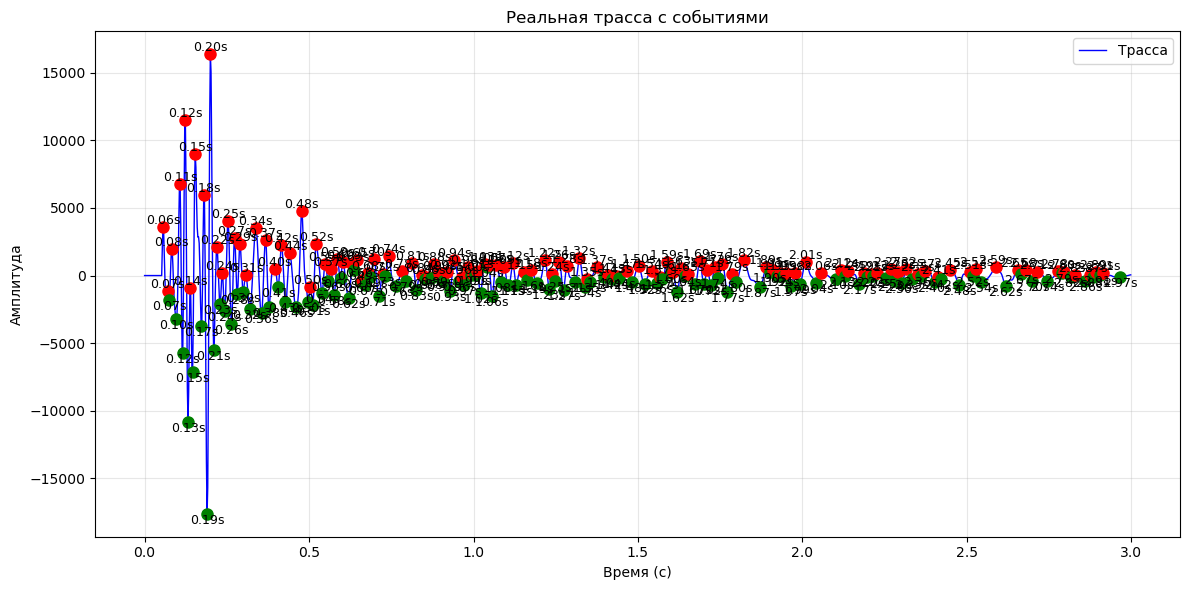

In [12]:
loader.plot_trace(real_trace, title="Реальная трасса с событиями", events=events)


Загружено 3 трасс: [0, 100, 200]


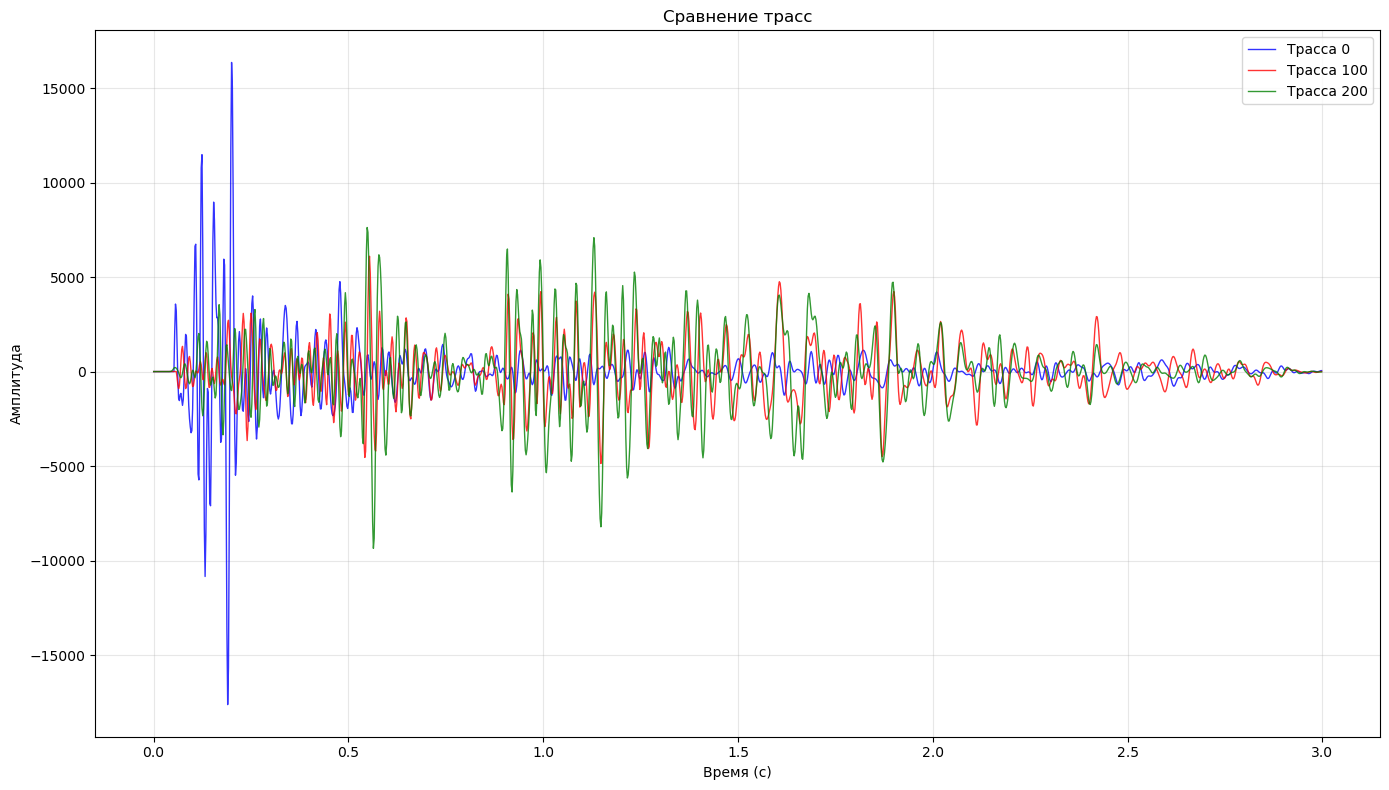

In [13]:
# 6. Сравниваем несколько трасс
traces = loader.load_multiple_traces([0, 100, 200])
loader.plot_multiple_traces(traces, titles=["Трасса 0", "Трасса 100", "Трасса 200"])

In [14]:
# ПРОГА ОРИЕНТИРУЕТСЯ ОТ ВРЕМЕНИ, НАДО ОТ ОТСЧЕТОВ (на потом)


Задание 2: Ручной подбор параметров для трассы 0 (ИСПРАВЛЕННЫЙ)

Загружена трасса 0

Анализ трассы:
  Найдено событий: 213
  Оценка доминантной частоты: 44.8 Гц

Выделенные горизонты (3):
  Горизонт 1: t = 0.124 с, A = 11476.797 (positive)
  Горизонт 2: t = 0.190 с, A = -17622.605 (negative)
  Горизонт 3: t = 0.200 с, A = 16357.457 (positive)

Выделенные горизонты для трассы 0:
  Горизонт 1: время = 0.124 с, амплитуда = 11476.8
  Горизонт 2: время = 0.190 с, амплитуда = -17622.6
  Горизонт 3: время = 0.200 с, амплитуда = 16357.5

Начальная модель с контрастными параметрами:
ТЕКУЩАЯ МОДЕЛЬ

Геометрия слоёв:
  Глубины границ (м): ['124.0', '190.0', '200.0']
  Скорости (м/с): ['1800', '2500', '3200', '4000']
  Плотности (кг/м³): ['2100', '2300', '2500', '2700']

  Детальная таблица слоёв:
  ----------------------------------------------------------------------
  Слой   Глубина (м)  V (м/с)    ρ (кг/м³)    Импеданс       
  -----------------------------------------------------------------

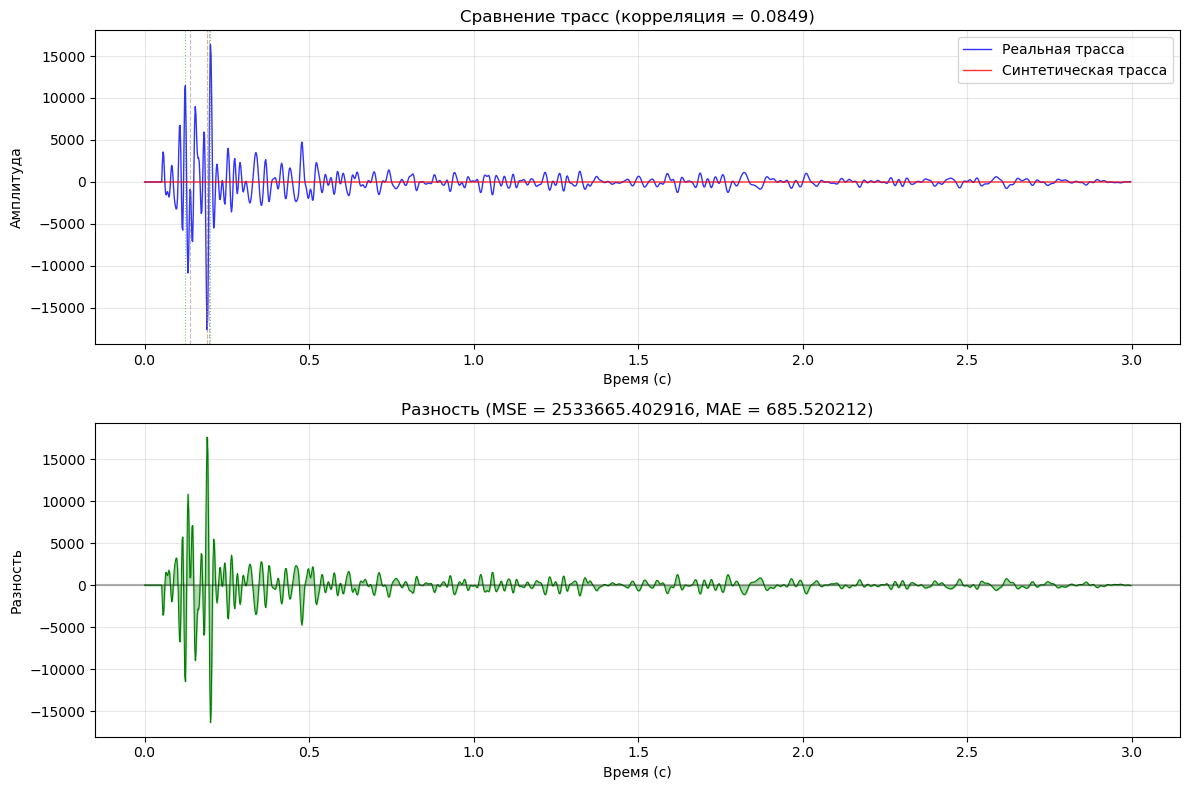

Корреляция после подбора частоты: 0.0849



Нажмите Enter, чтобы продолжить... 



--- Итерация 2: Ручная настройка амплитуд (масштабирование плотностей) ---
Текущие плотности: [2100 2300 2500 2700]
Новые плотности: [2100 2530 2375 2835]
Новые коэффициенты отражения: ['0.252', '0.092', '0.197']
Корреляция после подбора амплитуд: 0.0623


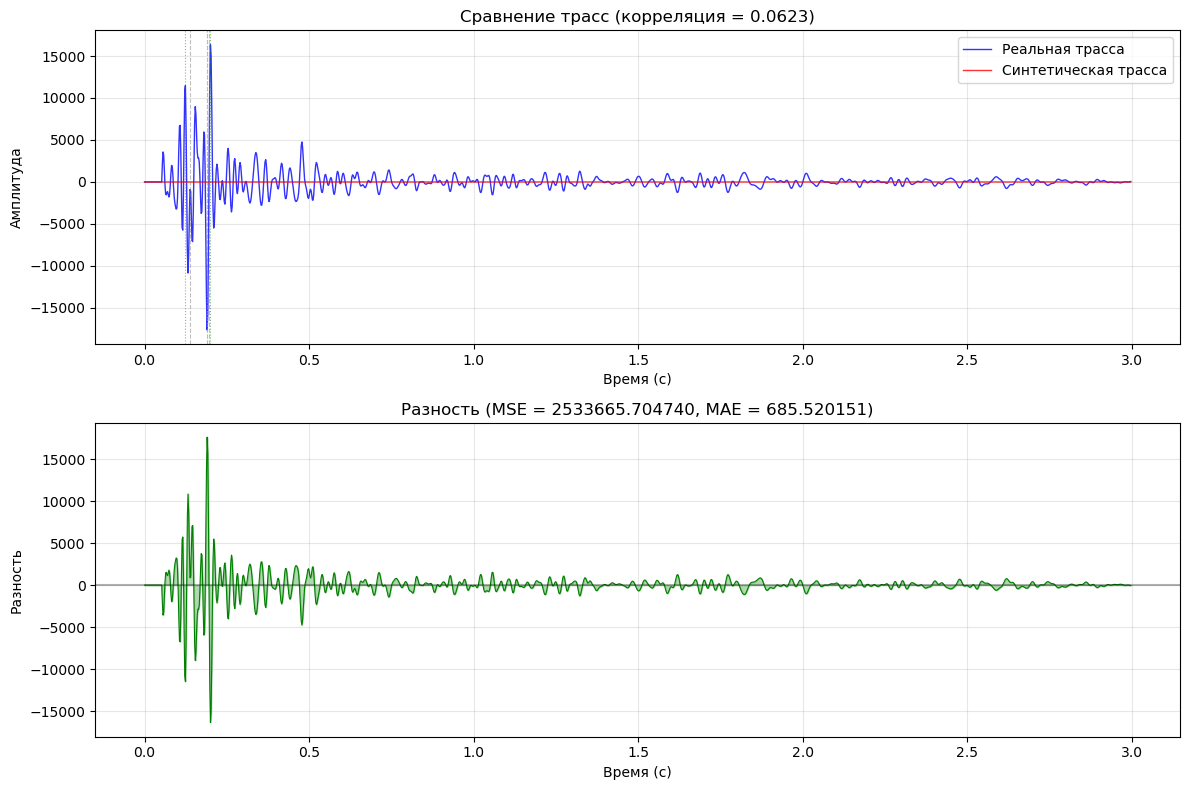


Нажмите Enter, чтобы продолжить... 



--- Итерация 3: Настройка времен (скоростей и глубин) ---
Текущие скорости: [1800 2500 3200 4000]
Текущие глубины: [124. 190. 200.]
Новые скорости: [1800 2375 3360 4000]
Новые глубины: [124.  186.2 198. ]
Корреляция после подбора времен: 0.0471


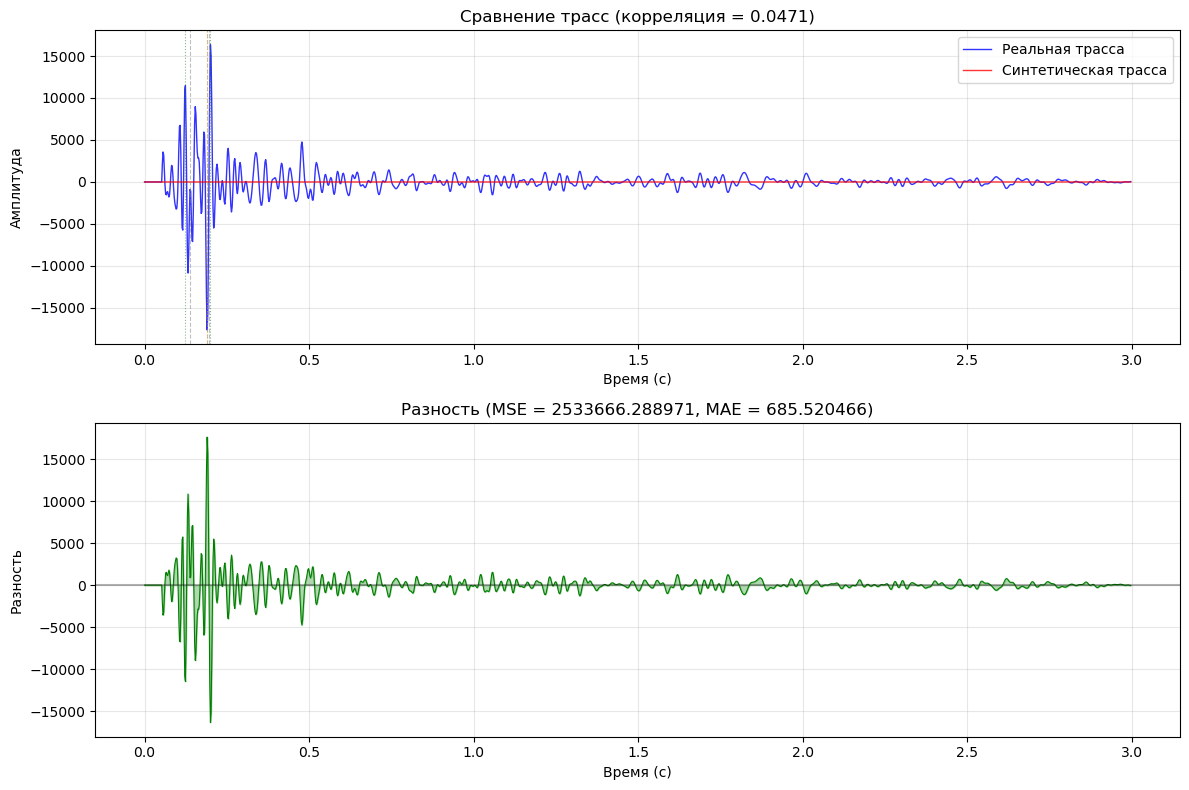


--- Финальная оценка ---
Финальная корреляция Пирсона: 0.0471
Финальная корреляция Спирмена: 0.0357
ТЕКУЩАЯ МОДЕЛЬ

Геометрия слоёв:
  Глубины границ (м): ['124.0', '186.2', '198.0']
  Скорости (м/с): ['1800', '2375', '3360', '4000']
  Плотности (кг/м³): ['2100', '2530', '2375', '2835']

  Детальная таблица слоёв:
  ----------------------------------------------------------------------
  Слой   Глубина (м)  V (м/с)    ρ (кг/м³)    Импеданс       
  ----------------------------------------------------------------------
  0      124.0        1800       2100         3780000.00     
  1      186.2        2375       2530         6008750.00     
  2      198.0        3360       2375         7980000.00     
  3      ∞            4000       2835         11340000.00    

Параметры сигнала:
  Частота вейвлета: 72.1 Гц
  Уровень шума: 0.0000
  dt: 2.000 мс
  Длительность: 3.00 с

Результаты сохранены в model_results_trace0_fixed.txt


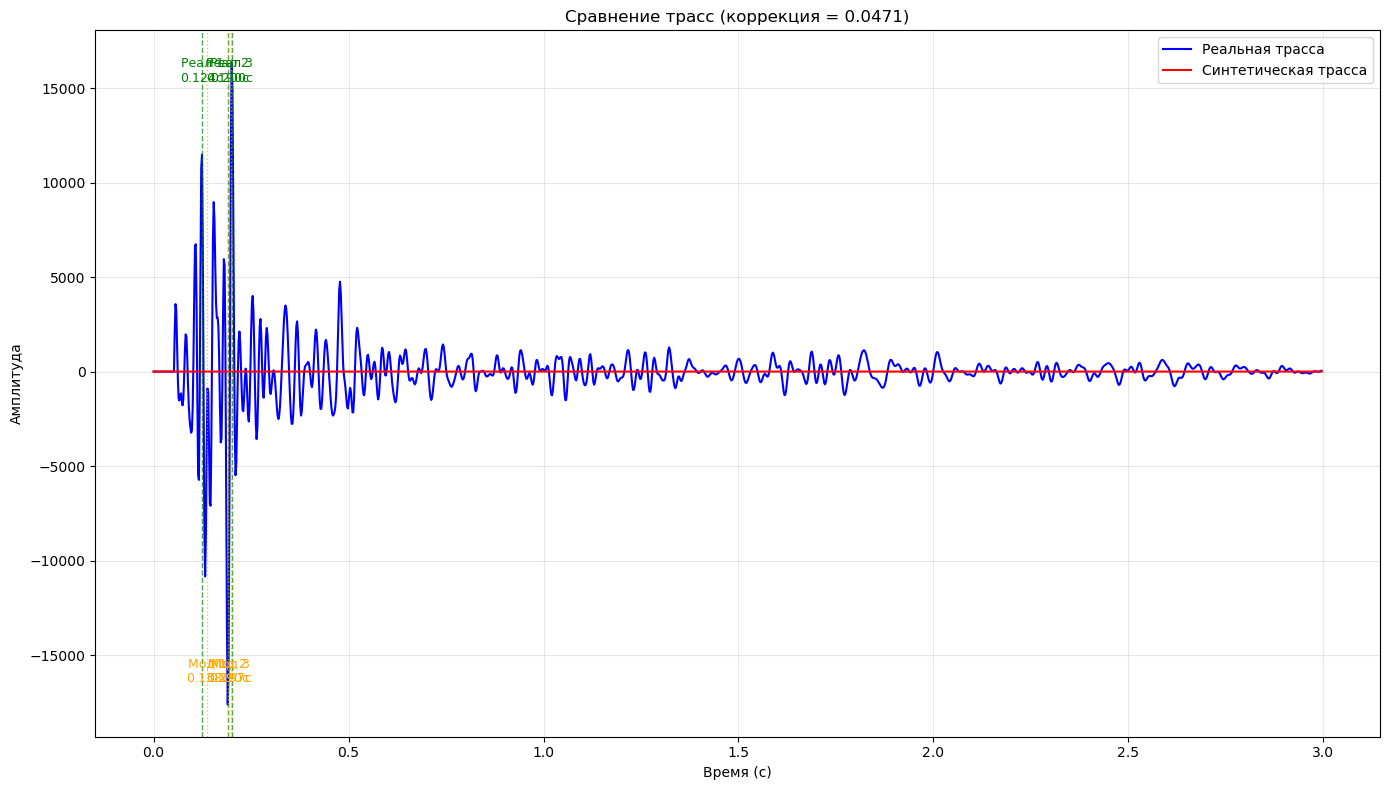


Советы для улучшения корреляции:
1. Если синтетическая трасса все еще слишком слабая - увеличьте контраст скоростей/плотностей
2. Если пики не совпадают по времени - корректируйте скорости и глубины
3. Если фаза отражений не совпадает (+/-) - меняйте порядок плотностей
4. Повторяйте итерации 2 и 3, пока корреляция не станет > 0.8


In [15]:
# --- Исправленный код для Задания 2 с реалистичными начальными параметрами ---
print("\n" + "="*60)
print("Задание 2: Ручной подбор параметров для трассы 0 (ИСПРАВЛЕННЫЙ)")
print("="*60)

# 1. Загружаем реальную трассу (индекс 0)
real_trace_0 = loader.load_trace(trace_index=0)

# 2. Выделяем события и выбираем 3 наиболее значимых горизонта
events_0, dominant_freq_0 = loader.extract_events(real_trace_0, prominence=0.05)
horizons_0 = loader.get_horizons_from_events(events_0, min_amplitude=None, max_events=3)

print(f"\nВыделенные горизонты для трассы 0:")
for i, h in enumerate(horizons_0):
    print(f"  Горизонт {i+1}: время = {h['time']:.3f} с, амплитуда = {h['amplitude']:.1f}")

# 3. Создаем генератор
model = SeismicTraceGenerator(dt=loader.dt_sec, total_time=loader.time_axis[-1], 
                              wavelet_freq=dominant_freq_0, noise_level=0.0)

# 4. Задаем РЕАЛИСТИЧНУЮ начальную модель с существенными контрастами
#    Важно: импедансы слоёв должны заметно отличаться!
#    Импеданс Z = плотность * скорость

# Глубины (м) - оцениваем из времен: глубина ≈ (время_с * 2000) / 2
#    Используем среднюю скорость 2000 м/с
depths_initial = np.array([h['time'] * 1000 for h in horizons_0])  # время(с) * 1000 ≈ глубина(м)

# Скорости (м/с) и плотности (кг/м³) с ХОРОШИМИ КОНТРАСТАМИ
#    Контраст импедансов создает отражения!
velocities_initial = np.array([1800,   # Слой 1: верхний (песок)
                               2500,   # Слой 2: уплотненный песок/глина
                               3200,   # Слой 3: известняк
                               4000])  # Слой 4: фундамент

densities_initial = np.array([2100,    # Плотность слоя 1
                              2300,    # Плотность слоя 2
                              2500,    # Плотность слоя 3
                              2700])   # Плотность слоя 4

print("\nНачальная модель с контрастными параметрами:")
model.set_horizons(depths_initial, velocities_initial, densities_initial)
model.print_summary()

# Посмотрим коэффициенты отражения
_, _, coeffs_initial = model.get_reflectivity_series()
print(f"\nНачальные коэффициенты отражения: {[f'{c:.3f}' for c in coeffs_initial]}")

# 5. Итеративный подбор

print("\n--- Итерация 1: Оптимизация частоты вейвлета ---")
model.optimize_wavelet_freq(real_trace_0, freq_range=(10, 80))
model.plot_comparison(real_trace_0, events=horizons_0)
print(f"Корреляция после подбора частоты: {model.compare_with_real(real_trace_0)['pearson']:.4f}")

input("\nНажмите Enter, чтобы продолжить...")

print("\n--- Итерация 2: Ручная настройка амплитуд (масштабирование плотностей) ---")

# Анализируем график: какие амплитуды нужно изменить?
# Плотность влияет на импеданс: увеличение плотности слоя УВЕЛИЧИВАЕТ импеданс
# Коэффициент отражения = (Z2 - Z1) / (Z2 + Z1)

current_densities = model.densities.copy()
print(f"Текущие плотности: {current_densities}")

# Ручной подбор масштабов (экспериментируйте с этими числами!)
# Начнем с небольших изменений
scale2 = 1.10   # Увеличим плотность слоя 2 на 10%
scale3 = 0.95   # Уменьшим плотность слоя 3 на 5%
scale4 = 1.05   # Увеличим плотность слоя 4 на 5%

new_densities = current_densities.copy()
new_densities[1] *= scale2
new_densities[2] *= scale3
new_densities[3] *= scale4
model.densities = new_densities

print(f"Новые плотности: {model.densities}")

# Пересчитаем коэффициенты
_, _, coeffs_new = model.get_reflectivity_series()
print(f"Новые коэффициенты отражения: {[f'{c:.3f}' for c in coeffs_new]}")

metrics = model.compare_with_real(real_trace_0)
print(f"Корреляция после подбора амплитуд: {metrics['pearson']:.4f}")
model.plot_comparison(real_trace_0, events=horizons_0)

input("\nНажмите Enter, чтобы продолжить...")

print("\n--- Итерация 3: Настройка времен (скоростей и глубин) ---")

# Теперь подстроим времена прихода
# Скорость влияет на время: чем выше скорость, тем меньше время прихода

current_velocities = model.velocities.copy()
current_depths = model.depths.copy()

print(f"Текущие скорости: {current_velocities}")
print(f"Текущие глубины: {current_depths}")

# Ручная настройка (экспериментируйте!)
# Изменяем скорости слоев
vel_scale2 = 0.95   # Уменьшим скорость слоя 2 на 5% (время увеличится)
vel_scale3 = 1.05   # Увеличим скорость слоя 3 на 5% (время уменьшится)
vel_scale4 = 1.00   # Без изменений

new_velocities = current_velocities.copy()
new_velocities[1] *= vel_scale2
new_velocities[2] *= vel_scale3
new_velocities[3] *= vel_scale4
model.velocities = new_velocities

# Также можно подкорректировать глубины
depth_scale = np.array([1.00, 0.98, 0.99])  # Корректируем глубины горизонтов
new_depths = current_depths * depth_scale
model.depths = new_depths

print(f"Новые скорости: {model.velocities}")
print(f"Новые глубины: {model.depths}")

metrics = model.compare_with_real(real_trace_0)
print(f"Корреляция после подбора времен: {metrics['pearson']:.4f}")
model.plot_comparison(real_trace_0, events=horizons_0)

print("\n--- Финальная оценка ---")
metrics_final = model.compare_with_real(real_trace_0)
print(f"Финальная корреляция Пирсона: {metrics_final['pearson']:.4f}")
print(f"Финальная корреляция Спирмена: {metrics_final['spearman']:.4f}")

model.print_summary()
model.save_results(real_trace_0, filename="model_results_trace0_fixed.txt")

# Финальный график с отметками горизонтов
plt.figure(figsize=(14, 8))
synth_trace, times, coeffs = model.generate_trace()
time_axis = model.time[:min(len(synth_trace), len(real_trace_0))]
plt.plot(time_axis, real_trace_0[:len(time_axis)], 'b-', label='Реальная трасса', linewidth=1.5)
plt.plot(time_axis, synth_trace[:len(time_axis)], 'r-', label='Синтетическая трасса', linewidth=1.5)

# Отметим реальные горизонты
for i, h in enumerate(horizons_0):
    plt.axvline(x=h['time'], color='g', linestyle='--', alpha=0.7, linewidth=1)
    plt.text(h['time'], plt.ylim()[1]*0.85, f"Реал {i+1}\n{h['time']:.3f}c", 
             ha='center', fontsize=9, color='green')

# Отметим модельные горизонты
for i, t in enumerate(times):
    plt.axvline(x=t, color='orange', linestyle=':', alpha=0.7, linewidth=1)
    plt.text(t, plt.ylim()[0]*0.85, f"Мод {i+1}\n{t:.3f}c", 
             ha='center', fontsize=9, color='orange')

plt.title(f'Сравнение трасс (коррекция = {metrics_final["pearson"]:.4f})')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nСоветы для улучшения корреляции:")
print("1. Если синтетическая трасса все еще слишком слабая - увеличьте контраст скоростей/плотностей")
print("2. Если пики не совпадают по времени - корректируйте скорости и глубины")
print("3. Если фаза отражений не совпадает (+/-) - меняйте порядок плотностей")
print("4. Повторяйте итерации 2 и 3, пока корреляция не станет > 0.8")